# Supplementary Tables  from per-domain annotations
Input: one row per GH18 domain (`260926_perdomain_annotations.csv`).
Set the options in the first code cell, then run all.

In [39]:
import re
import pandas as pd

# ---- options ---------------------------------------------------------------
INFILE = "../data/annotation/260926_perdomain_annotations.csv"   # path to per-domain CSV
OUTDIR = "."                                   # where table CSVs are written

# Drop domain rows whose label is not a GH18 model and that have no hmmsearch
# score (currently 2 PF01522 rows). False = keep them, as in the raw file.
DROP_NONGH18_ROWS = True
NONGH18_SIGNATURES = ["PF01522", "cd00413"]

# Signatures listed in the tables but not GH18 models (kept, just flagged).
# Edit to apply one consistent inclusion rule to Tables 2 and 3.
EXCLUDE_FROM_TABLE2 = []            # e.g. ["cd00413", "SSF51989"]

# Table 4: signal motifs rather than domains. False reproduces the draft table.
EXCLUDE_SIGNAL_MOTIFS = False
SIGNAL_MOTIFS = ["PS51257", "PS51318"]
TOP_N = 15
KEEP_TIES = True                    # extend past TOP_N if the Nth value is tied

# Descriptions copied from the draft Table 2 (not present in the input file).
DESCRIPTIONS = {
    "G3DSA:2.10.10.20:FF:000001": "Secreted chitinase",
    "G3DSA:2.60.40.10:FF:002602": "Chitinase",
    "G3DSA:2.60.40.10:FF:002609": "Chitinase",
    "G3DSA:2.60.40.10:FF:003164": "Chitinase A",
    "G3DSA:3.20.20.370": "Glycoside hydrolase/deacetylase",
    "G3DSA:3.20.20.80": "Glycosidases",
    "G3DSA:3.30.20.10:FF:000003": "Chitinase",
    "PF00704": "Glycosyl hydrolases family 18",
    "PF06483": "Chitinase C",
    "PS51910": "Glycosyl hydrolases family 18 (GH18) domain profile",
    "PTHR10963": "Glycosyl hydrolase related",
    "PTHR22595": "Chitinase-related",
    "SSF51445": "(Trans)glycosidases",
    "SSF51989": "Glycosyl hydrolases family 6, cellulases",
    "cd00413": "GH16",
}

## Load and sanity-check

In [40]:
d = pd.read_csv(INFILE, low_memory=False)
print(f"{len(d):,} domain rows, {d.Entry.nunique():,} sequences")

# fastaID encodes 'i of n' GH18 domains; compare with n_GH18_domains
fid = d.fastaID.str.extract(r"\|(\d+)of(\d+)$").astype(int)
d["dom_pos"], d["dom_total_fastaid"] = fid[0], fid[1]

# n_GH18_domains must be constant within a sequence
assert d.groupby("Entry").n_GH18_domains.nunique().max() == 1

bad = d[d.dom_total_fastaid != d.n_GH18_domains]
print(f"fastaID 'of n' disagrees with n_GH18_domains in {len(bad)} rows")
display(bad[["fastaID", "signature_accession", "score", "domains_pfamscan", "n_GH18_domains"]])

if DROP_NONGH18_ROWS:
    drop = d.signature_accession.isin(NONGH18_SIGNATURES) & d.score.isna()
    print(f"Dropping {drop.sum()} non-GH18 domain rows: {d.loc[drop, 'fastaID'].tolist()}")
    d = d[~drop].copy()

# rows per sequence should now equal n_GH18_domains
rows_per_seq = d.groupby("Entry").size()
n_per_seq = d.groupby("Entry").n_GH18_domains.first()
mism = (rows_per_seq != n_per_seq).sum()
print(f"sequences where row count != n_GH18_domains: {mism}")

41,904 domain rows, 39,582 sequences
fastaID 'of n' disagrees with n_GH18_domains in 4 rows


,fastaID,signature_accession,score,domains_pfamscan,n_GH18_domains
31881,A0A9E2SB20|1of2,PF00704,259.9,GH18[184-420] PF00535[791-960],1
31882,A0A9E2SB20|2of2,PF01522,NaN,GH18[184-420] PF00535[791-960],1
36913,A0AAW4NQY0|1of2,PF00704,249.6,GH18[166-410] PF00535[780-946],1
36914,A0AAW4NQY0|2of2,PF01522,NaN,GH18[166-410] PF00535[780-946],1


Dropping 4 non-GH18 domain rows: ['A0A2S0KPP8|1of2', 'A0A364Y199|2of2', 'A0A9E2SB20|2of2', 'A0AAW4NQY0|2of2']
sequences where row count != n_GH18_domains: 2


## Supplementary Table 2
Sequences (not domains) per signature and GH18 domain count. A sequence is counted
once per signature even if several of its domains carry that label. Rows are not
mutually exclusive: a sequence whose domains carry different labels appears in each row.

In [54]:
pairs = d.drop_duplicates(["Entry", "signature_accession"])
t2 = (pd.crosstab(pairs.signature_accession, pairs.n_GH18_domains)
        .reindex(columns=[1, 2, 3], fill_value=0))
t2 = t2.drop(index=[s for s in EXCLUDE_FROM_TABLE2 if s in t2.index])
t2.index.name = "Signature"
t2.columns.name = "GH18 domains"
t2.insert(0, "Description", t2.index.map(lambda s: DESCRIPTIONS.get(s, "–")))
t2 = t2.sort_index()
# ---- source data for Supplementary Table 2 ----
OUT_T2 = "../results/source_data/Stable2_source_data.csv"

t2_source = (pairs.loc[~pairs.signature_accession.isin(EXCLUDE_FROM_TABLE2),
                       ["Entry", "n_GH18_domains", "signature_accession"]]
               .rename(columns={"n_GH18_domains": "Total_num_GH18domains",
                                "signature_accession": "Signature"})
               .sort_values(["Entry", "Signature"])
               .reset_index(drop=True))

# round-trip check: crosstab of the CSV must reproduce t2's counts
chk = (pd.crosstab(t2_source.Signature, t2_source.Total_num_GH18domains)
         .reindex(index=t2.index, columns=[1, 2, 3], fill_value=0))
assert (chk.values == t2[[1, 2, 3]].values).all(), "CSV does not reproduce Table 2"

t2_source.to_csv(OUT_T2, index=False, encoding="utf-8-sig")
print(f"wrote {len(t2_source)} rows ({t2_source.Entry.nunique()} entries) -> {OUT_T2}")
display(t2_source.head())
# cross-check: class totals from sequences, independent of labels
print("sequences per class:", n_per_seq.value_counts().sort_index().to_dict())
t2

wrote 41638 rows (39582 entries) -> ../results/source_data/Stable2_source_data.csv


,Entry,Total_num_GH18domains,Signature
0,A0A010YG22,1,PS51910
1,A0A011PM39,2,G3DSA:3.20.20.370
2,A0A011PM39,2,PF00704
3,A0A011PXQ4,2,G3DSA:3.20.20.370
4,A0A011PXQ4,2,PF00704


sequences per class: {1: 37323, 2: 2198, 3: 61}


GH18 domains,Description,1,2,3
Signature,,,,
G3DSA:2.10.10.20:FF:000001,Secreted chitinase,0,129,2
G3DSA:2.60.40.10:FF:002602,Chitinase,0,4,7
G3DSA:2.60.40.10:FF:002609,Chitinase,0,0,7
G3DSA:2.60.40.10:FF:003164,Chitinase A,0,1,0
G3DSA:3.10.50.10,–,0,4,0
G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,0,1389,2
G3DSA:3.20.20.80,Glycosidases,0,5,4
G3DSA:3.30.1490.230,–,0,1,0
G3DSA:3.30.20.10:FF:000003,Chitinase,0,2,0


## Supplementary Table 3
Signatures whose sequences all fall in a single class. Caveat: each domain carries
only one label, so "exclusive" means *only ever chosen as the label* in that class,
not absent from the other classes in the full InterProScan output.

In [55]:
counts = t2[[1, 2, 3]]
t3 = counts[(counts > 0).sum(axis=1) == 1].copy()
t3.columns = ["Class 1", "Class 2", "Class 3"]
t3["_order"] = t3.idxmax(axis=1).map({"Class 1": 1, "Class 2": 2, "Class 3": 3})
t3["_n"] = t3[["Class 1", "Class 2", "Class 3"]].sum(axis=1)
t3 = (t3.sort_values(["_order", "_n"], ascending=[True, False])
        .drop(columns=["_order", "_n"]))
t3.index = [f"{s} ({DESCRIPTIONS[s]})" if s in DESCRIPTIONS else s for s in t3.index]
t3.index.name = "Signature"

# ---- source data for Supplementary Table 3 ----
OUT_T3 = "../results/source_data/Stable3_source_data.csv"

# raw signature IDs (t3's index now carries descriptions, so recompute from counts)
class_restricted = counts.index[(counts > 0).sum(axis=1) == 1]

t3_source = (t2_source[t2_source.Signature.isin(class_restricted)
                       & t2_source.Total_num_GH18domains.isin([1, 2, 3])]
               .reset_index(drop=True))

# round-trip check: crosstab of the CSV must reproduce t3's counts
chk = (pd.crosstab(t3_source.Signature, t3_source.Total_num_GH18domains)
         .reindex(index=class_restricted, columns=[1, 2, 3], fill_value=0))
assert (chk.values == counts.loc[class_restricted].values).all(), "CSV does not reproduce Table 3"

t3_source.to_csv(OUT_T3, index=False, encoding="utf-8-sig")
print(f"wrote {len(t3_source)} rows ({t3_source.Entry.nunique()} entries, "
      f"{t3_source.Signature.nunique()} signatures) -> {OUT_T3}")
#display(t3_source.head())
t3

wrote 263 rows (263 entries, 8 signatures) -> ../results/source_data/Stable3_source_data.csv


,Class 1,Class 2,Class 3
Signature,,,
PF06483 (Chitinase C),0,231,0
PIRSR001103-1,0,12,0
PTHR10963 (Glycosyl hydrolase related),0,5,0
G3DSA:3.10.50.10,0,4,0
G3DSA:3.30.20.10:FF:000003 (Chitinase),0,2,0
G3DSA:2.60.40.10:FF:003164 (Chitinase A),0,1,0
G3DSA:3.30.1490.230,0,1,0
G3DSA:2.60.40.10:FF:002609 (Chitinase),0,0,7


## Supplementary Table 4
Auxiliary (non-GH18) signatures from the `domains` column, one row per sequence.
Both definitions of "count" are given: total occurrences (the draft table) and number
of sequences containing the signature. Tandem repeats make these differ.

In [62]:
seq = d.drop_duplicates("Entry")[["Entry", "domains"]]
aux = (seq.assign(sig=seq.domains.str.split())
          .explode("sig")
          .query("sig != 'GH18'"))
if EXCLUDE_SIGNAL_MOTIFS:
    aux = aux[~aux.sig.isin(SIGNAL_MOTIFS)]

aux_all = pd.DataFrame({
    "Occurrences": aux.sig.value_counts(),
    "Sequences": aux.drop_duplicates(["Entry", "sig"]).sig.value_counts(),
})
aux_all.index.name = "Signature"
aux_all = aux_all.sort_values(["Occurrences", "Sequences"], ascending=False)

cutoff = aux_all.Occurrences.iloc[TOP_N - 1]
t4 = aux_all[aux_all.Occurrences >= cutoff] if KEEP_TIES else aux_all.head(TOP_N)
if len(t4) > TOP_N:
    print(f"Tie at rank {TOP_N} (value {cutoff}); showing {len(t4)} rows.")
print(f"{len(aux_all)} distinct auxiliary signatures in total")
# ---- source data for Supplementary Table 4 ----
OUT_T4 = "../results/source_data/Stable4_source_data.csv"

# one row per domain occurrence, with its 1-based position in the full architecture (GH18 included)
tok = seq.assign(Signature=seq.domains.str.split())
tok["domain_position_in_architecture"] = tok.Signature.apply(lambda t: list(range(1, len(t) + 1)))
occ = (tok.explode(["Signature", "domain_position_in_architecture"])
          .query("Signature != 'GH18'"))
if EXCLUDE_SIGNAL_MOTIFS:
    occ = occ[~occ.Signature.isin(SIGNAL_MOTIFS)]

t4_source = (occ[occ.Signature.isin(t4.index)]
               [["Entry", "domain_position_in_architecture", "Signature"]]
               .astype({"domain_position_in_architecture": int})
               .sort_values(["Entry", "domain_position_in_architecture"])
               .reset_index(drop=True))

# round-trip check: Occurrences = rows, Sequences = distinct entries
chk = pd.DataFrame({
    "Occurrences": t4_source.Signature.value_counts(),
    "Sequences": t4_source.drop_duplicates(["Entry", "Signature"]).Signature.value_counts(),
}).reindex(t4.index)
assert (chk.values == t4[["Occurrences", "Sequences"]].values).all(), "CSV does not reproduce Table 4"

t4_source.to_csv(OUT_T4, index=False, encoding="utf-8-sig")
print(f"wrote {len(t4_source)} rows ({t4_source.Entry.nunique()} entries, "
      f"{t4_source.Signature.nunique()} signatures) -> {OUT_T4}")
t4

Tie at rank 15 (value 719); showing 16 rows.
367 distinct auxiliary signatures in total
wrote 42187 rows (22610 entries, 16 signatures) -> ../results/Stable4_source_data.csv


,Occurrences,Sequences
Signature,,
PF02839,5964,4969
PF01476,5829,2887
PF00041,5563,5409
PF00553,3486,3278
SM00495,2828,1948
PS51257,2805,2805
PF17957,2709,1238
PF02018,2612,2612
G3DSA:2.60.40.10,2235,1903


Stable 6

In [44]:
# ---- Supplementary Table 6: unique auxiliary signatures per functional category ----
# Optional: CSV with your manual Table 6 assignment, columns:
#   signature, broad_class, functional_category
# Leave as None to use the categories stored in the input file's broad_categories column.
MAPPING_CSV = None

# Signature-level category reference (same Global 12-category scheme as `broad_categories`),
# used only to fill signatures that can't be recovered positionally.
SIG_CSV = "../data/annotation/05_master_categories/signature_broad_categories_global_mapping.csv"
FILL_FROM_CSV = ["G3DSA:2.60.40.1220"]   # set to None to fill every uncategorised signature

seq = d.drop_duplicates("Entry")[["Entry", "domains", "broad_categories"]].copy()
seq["aux"] = seq.domains.str.split().apply(lambda t: [x for x in t if x != "GH18"])
seq["cats"] = seq.broad_categories.fillna("").apply(lambda x: x.split("|") if x else [])

# broad_categories is a '|'-joined list aligned position-by-position with the
# non-GH18 tokens in `domains`, except that uncategorised signatures are skipped.
# Build the map from sequences where the two lists have equal length ...
ok = seq.aux.str.len() == seq.cats.str.len()
pairs = pd.DataFrame(
    [(s, c) for S, C in zip(seq.aux[ok], seq.cats[ok]) for s, c in zip(S, C)],
    columns=["signature", "category"]).drop_duplicates()
conflicts = pairs.signature.duplicated(keep=False)
assert not conflicts.any(), pairs[conflicts]           # each signature -> 1 category
sig2cat = pairs.set_index("signature").category

all_aux = pd.Series(sorted({s for S in seq.aux for s in S}), name="signature")
uncat_input = sorted(set(all_aux) - set(sig2cat.index))
print(f"{len(all_aux)} unique auxiliary signatures; {len(sig2cat)} categorised from input")
print(f"uncategorised in input file: {uncat_input}")

# ---- fill categories that can't be recovered positionally ----
ref = (pd.read_csv(SIG_CSV, encoding="utf-8-sig")
         .set_index("signature_accession").broad_category)

# sanity check: CSV must agree with the positional map wherever both exist
shared = sig2cat.index.intersection(ref.index)
disagree = sig2cat[shared][sig2cat[shared] != ref[shared]]
assert disagree.empty, disagree

for s in (uncat_input if FILL_FROM_CSV is None else FILL_FROM_CSV):
    if s in sig2cat.index:
        continue
    if s in ref.index and pd.notna(ref[s]):
        sig2cat[s] = ref[s]
        print(f"filled {s} -> {ref[s]!r} (from {SIG_CSV})")
    else:
        print(f"warning: {s} has no category in {SIG_CSV}")

uncat = sorted(set(all_aux) - set(sig2cat.index))
print(f"{len(sig2cat)} categorised after fill; still uncategorised: {uncat}")

# ... and check the rest align once the signatures the INPUT skipped are removed
rest = seq[~ok]
realigned = (rest.aux.apply(lambda t: [x for x in t if x not in uncat_input]).str.len()
             == rest.cats.str.len())
print(f"{len(rest)} sequences with unequal lists; {realigned.sum()} realign after "
      f"skipping uncategorised signatures")

# ---- add the dropped non-GH18 domains as auxiliary signatures ----
# Labels must use the same (Global) scheme as broad_categories
REASSIGN = {}#"PF01522": "Catalytic partner domains (non-GH18)",
            #"cd00413": "Catalytic partner domains (non-GH18)"}

known_cats = set(sig2cat.unique())
for sig, cat in REASSIGN.items():
    assert cat in known_cats, f"{sig}: {cat!r} is not an existing category"

raw = pd.read_csv(INFILE, usecols=["Entry", "signature_accession"])
moved_aux = raw[raw.signature_accession.isin(list(REASSIGN))]
print("adding as auxiliary:"); display(moved_aux)

for sig, cat in REASSIGN.items():
    if sig in sig2cat.index and sig2cat[sig] != cat:
        print(f"warning: {sig} already categorised as {sig2cat[sig]!r}; overriding")
    sig2cat[sig] = cat

extra_aux = moved_aux.groupby("Entry").signature_accession.apply(list)
seq["aux"] = [a + extra_aux.get(e, []) for e, a in zip(seq.Entry, seq.aux)]
all_aux = pd.Series(sorted({s for S in seq.aux for s in S}), name="signature")
uncat = sorted(set(all_aux) - set(sig2cat.index))
print(f"{len(all_aux)} unique auxiliary signatures after reassignment; "
      f"uncategorised: {uncat}")

# sequences carrying each signature (useful alongside the signature counts)
n_seq = seq.explode("aux").drop_duplicates(["Entry", "aux"]).aux.value_counts()

if MAPPING_CSV is None:
    t6 = (sig2cat.to_frame()
            .assign(n_seq=lambda x: x.index.map(n_seq))
            .groupby("category")
            .agg(n_signatures=("n_seq", "size"), n_sequences_with=("n_seq", "sum"))
            .sort_values("n_signatures", ascending=False))
    t6.loc["(uncategorised)"] = [len(uncat), sum(n_seq.get(s, 0) for s in uncat)]
    t6.columns = ["Unique auxiliary signatures", "Sum of sequences per signature"]
else:
    mp = pd.read_csv(MAPPING_CSV).drop_duplicates("signature")
    missing = sorted(set(all_aux) - set(mp.signature))
    not_in_data = sorted(set(mp.signature) - set(all_aux))
    print(f"in data but not in mapping ({len(missing)}): {missing}")
    print(f"in mapping but not in data ({len(not_in_data)}): {not_in_data}")
    mp = mp[mp.signature.isin(all_aux)]
    t6 = (mp.groupby(["broad_class", "functional_category"], sort=False)
            .signature.nunique().rename("Unique auxiliary signatures").to_frame())

print(f"total signatures in table: {t6.iloc[:, 0].sum()}")
t6

367 unique auxiliary signatures; 367 categorised from input
uncategorised in input file: []
367 categorised after fill; still uncategorised: []
0 sequences with unequal lists; 0 realign after skipping uncategorised signatures
adding as auxiliary:


,Entry,signature_accession


367 unique auxiliary signatures after reassignment; uncategorised: []
total signatures in table: 367


,Unique auxiliary signatures,Sum of sequences per signature
category,,
Unknowns / DUFs / broad structure-only calls,73,1918
"Ig-like & related β-sandwich scaffolds (adhesion, spacing)",71,10725
Catalytic partner domains (non-GH18),70,3073
Carbohydrate-binding modules (CBMs) — glycan grips,36,13777
Peptidoglycan-/cell-wall binding and SH3b group,27,5201
Surface anchoring & secretion/sorting systems,24,6209
Repeat/stalk & coiled-coil/IDRs (mechanical spacing),22,95
Lectins (β-trefoil / jacalin / C-type / others),18,1269
Redox/stress/metal helpers,10,41


Stables 11-13

In [56]:
# %% Cell 1 — inputs and datasets
import numpy as np, pandas as pd
from scipy.stats import fisher_exact

PARTNER_STATS = "../data/promiscuity/partner_stats_converted_protein_domains_interproscan_GH18replacedfprint.tsv"
MAPPING_CSV   = "../data/annotation/05_master_categories/signature_broad_categories_global_mapping.csv"
PHI_PROMISCUOUS = 0.009    # phi_GH18 >  this -> promiscuous
PHI_HOUSEKEEPER = -0.003   # phi_GH18 <  this -> housekeeper

ps = pd.read_csv(PARTNER_STATS, sep="\t")
mp = pd.read_csv(MAPPING_CSV, encoding="utf-8-sig")

glob = (mp[mp.in_global_dataset.astype(str).str.lower() == "true"]
          .rename(columns={"signature_accession": "Domain"})[["Domain", "broad_category"]])
glob = glob.merge(ps, on="Domain", how="left")
assert glob.phi_GH18.notna().all(), "Global signatures missing from partner stats"

prom = glob[glob.phi_GH18 > PHI_PROMISCUOUS]
hk   = glob[glob.phi_GH18 < PHI_HOUSEKEEPER]
print(f"Global: {len(glob)} | Promiscuous: {len(prom)} | Housekeeper: {len(hk)}")  # 365 | 40 | 21

CATS = sorted(glob.broad_category.unique())
assert len(CATS) == 12, CATS

Global: 367 | Promiscuous: 40 | Housekeeper: 21


In [57]:
# %% Cell 2 — helpers
def odds_ratio(a, n_a, b, n_b):
    """OR of category membership, subset a vs reference b (2x2: a, n_a-a / b, n_b-b)."""
    c, d = n_a - a, n_b - b
    if a == 0 and b == 0:
        return np.nan                       # 0/0: undefined
    if c * b == 0:
        return np.inf
    return (a * d) / (c * b)

def bh(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p)
    q = np.empty(n)
    q[o] = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.minimum(q, 1)

def fmt(k, n):
    return f"{k} ({100 * k / n:.1f}%)"

def enrichment_table(sub, ref, sub_label, ref_label, nested):
    """OR as published (sub vs full ref). If nested (ref contains sub), the Fisher test
    uses sub vs ref-minus-sub so the 2x2 table is valid."""
    ns, nr = len(sub), len(ref)
    rows = []
    for cat in CATS:
        a = int((sub.broad_category == cat).sum())
        b = int((ref.broad_category == cat).sum())
        b_test, nr_test = (b - a, nr - ns) if nested else (b, nr)
        _, p = fisher_exact([[a, ns - a], [b_test, nr_test - b_test]])
        rows.append({"Broad category": cat,
                     f"{sub_label} count": fmt(a, ns),
                     f"{ref_label} count": fmt(b, nr),
                     "Odds ratio": odds_ratio(a, ns, b, nr),
                     "_a": a, "_b": b, "Fisher p": p})
    t = pd.DataFrame(rows)
    t["BH q"] = bh(t["Fisher p"])
    return t.sort_values("Odds ratio", ascending=False, na_position="last").reset_index(drop=True)

In [58]:
# %% Cell 3 — Supplementary Table 11 (promiscuous vs global)
st11 = enrichment_table(prom, glob, "Promiscuous", "Global", nested=True)
st11.drop(columns=["_a", "_b"]).round({"Odds ratio": 2, "Fisher p": 3, "BH q": 3})

,Broad category,Promiscuous count,Global count,Odds ratio,Fisher p,BH q
0,Ig-like & related β-sandwich scaffolds (adhesi...,14 (35.0%),71 (19.3%),2.24,0.018,0.211
1,Lectins (β-trefoil / jacalin / C-type / others),4 (10.0%),18 (4.9%),2.15,0.120,0.419
2,Carbohydrate-binding modules (CBMs) — glycan g...,7 (17.5%),36 (9.8%),1.95,0.092,0.419
3,Repeat/stalk & coiled-coil/IDRs (mechanical sp...,2 (5.0%),22 (6.0%),0.83,1.000,1.000
4,Catalytic partner domains (non-GH18),6 (15.0%),70 (19.1%),0.75,0.670,1.000
5,Peptidoglycan-/cell-wall binding and SH3b group,2 (5.0%),27 (7.4%),0.66,0.753,1.000
6,Unknowns / DUFs / broad structure-only calls,4 (10.0%),73 (19.9%),0.45,0.140,0.419
7,Surface anchoring & secretion/sorting systems,1 (2.5%),24 (6.5%),0.37,0.495,1.000
8,Cellulosome / cellulolytic apparatus add-ons,0 (0.0%),3 (0.8%),0.00,1.000,1.000
9,DNA/RNA-binding & regulators occasionally fused,0 (0.0%),7 (1.9%),0.00,1.000,1.000


In [59]:
# %% Cell 4 — Supplementary Table 12 (housekeeper vs global)
st12 = enrichment_table(hk, glob, "Housekeeper", "Global", nested=True)
st12.drop(columns=["_a", "_b"]).round({"Odds ratio": 2, "Fisher p": 3, "BH q": 3})

,Broad category,Housekeeper count,Global count,Odds ratio,Fisher p,BH q
0,Carbohydrate-binding modules (CBMs) — glycan g...,5 (23.8%),36 (9.8%),2.87,0.044,0.522
1,Surface anchoring & secretion/sorting systems,3 (14.3%),24 (6.5%),2.38,0.150,0.775
2,Peptidoglycan-/cell-wall binding and SH3b group,3 (14.3%),27 (7.4%),2.10,0.194,0.775
3,Ig-like & related β-sandwich scaffolds (adhesi...,4 (19.0%),71 (19.3%),0.98,1.000,1.000
4,Lectins (β-trefoil / jacalin / C-type / others),1 (4.8%),18 (4.9%),0.97,1.000,1.000
5,Catalytic partner domains (non-GH18),3 (14.3%),70 (19.1%),0.71,0.777,1.000
6,Unknowns / DUFs / broad structure-only calls,2 (9.5%),73 (19.9%),0.42,0.273,0.820
7,Cellulosome / cellulolytic apparatus add-ons,0 (0.0%),3 (0.8%),0.00,1.000,1.000
8,DNA/RNA-binding & regulators occasionally fused,0 (0.0%),7 (1.9%),0.00,1.000,1.000
9,Outer-layer/periplasmic envelope helpers,0 (0.0%),6 (1.6%),0.00,1.000,1.000


In [60]:
# %% Cell 5 — Supplementary Table 13 (promiscuous vs housekeeper)
st13 = enrichment_table(prom, hk, "Promiscuous", "Housekeeper", nested=False)
st13 = st13[(st13._a + st13._b) > 0].copy()          # drop categories absent from both sets
st13["BH q"] = bh(st13["Fisher p"])                  # re-correct over the 8 retained categories

def pattern(r):
    pa, pb = 100 * r._a / len(prom), 100 * r._b / len(hk)
    if r._b == 0: return "Present only in promiscuous"
    if r._a == 0: return "Present only in housekeeper"
    orr = r["Odds ratio"]
    word = ("Higher in promiscuous" if orr > 1.2 else
            "Lower in promiscuous" if orr < 0.8 else "Similar")
    return f"{word} ({pa:.1f}% vs {pb:.1f}%)"

st13.insert(1, "Enrichment pattern (promiscuous vs housekeeper)", st13.apply(pattern, axis=1))
st13 = st13.drop(columns=["_a", "_b", "Promiscuous count", "Housekeeper count"])
st13.round({"Odds ratio": 2, "Fisher p": 3, "BH q": 3})

,Broad category,Enrichment pattern (promiscuous vs housekeeper),Odds ratio,Fisher p,BH q
0,Repeat/stalk & coiled-coil/IDRs (mechanical sp...,Present only in promiscuous,inf,0.541,0.981
1,Ig-like & related β-sandwich scaffolds (adhesi...,Higher in promiscuous (35.0% vs 19.0%),2.29,0.246,0.876
2,Lectins (β-trefoil / jacalin / C-type / others),Higher in promiscuous (10.0% vs 4.8%),2.22,0.651,0.981
3,Catalytic partner domains (non-GH18),Similar (15.0% vs 14.3%),1.06,1.000,1.000
4,Unknowns / DUFs / broad structure-only calls,Similar (10.0% vs 9.5%),1.06,1.000,1.000
5,Carbohydrate-binding modules (CBMs) — glycan g...,Lower in promiscuous (17.5% vs 23.8%),0.68,0.736,0.981
6,Peptidoglycan-/cell-wall binding and SH3b group,Lower in promiscuous (5.0% vs 14.3%),0.32,0.329,0.876
7,Surface anchoring & secretion/sorting systems,Lower in promiscuous (2.5% vs 14.3%),0.15,0.113,0.876


In [ ]:
# %% Cell 6 — print all three tables
from IPython.display import display

for title, t in [("Supplementary Table 11 — promiscuous vs global", st11),
                 ("Supplementary Table 12 — housekeeper vs global", st12),
                 ("Supplementary Table 13 — promiscuous vs housekeeper", st13)]:
    print(title)
    display(t.drop(columns=["_a", "_b"], errors="ignore")
             .round({"Odds ratio": 2, "Fisher p": 3, "BH q": 3}))

In [61]:
# %% Cell 7 — source data for Supplementary Tables 11–13 (long format)
OUT_CSV = "../results/source_data/Stable_11_to_13_source_data.csv"
INCLUDE_STATS = True     # False -> only domain_id, dataset, broad_category

cols = ["Domain", "broad_category"] + (["n_GH18", "T_GH18", "pi_GH18", "phi_GH18"] if INCLUDE_STATS else [])

source = pd.concat([prom[cols].assign(dataset="Promiscuous"),
                    hk[cols].assign(dataset="Housekeeper"),
                    glob[cols].assign(dataset="Global")], ignore_index=True)
source = source.rename(columns={"Domain": "domain_id"})
source = source[["domain_id", "dataset"] + [c for c in source.columns if c not in ("domain_id", "dataset")]]

# round-trip check: counts rebuilt from the CSV must match the tables
counts = source.groupby(["broad_category", "dataset"]).size().unstack(fill_value=0)
for label, sub in [("Promiscuous", prom), ("Housekeeper", hk), ("Global", glob)]:
    assert (counts[label] == sub.broad_category.value_counts().reindex(counts.index, fill_value=0)).all()

source.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print(f"wrote {len(source)} rows -> {OUT_CSV}")
print(source.dataset.value_counts().to_string())
display(counts[["Promiscuous", "Housekeeper", "Global"]])

wrote 428 rows -> ../results/source_data/Stable_11_to_13_source_data.csv
dataset
Global         367
Promiscuous     40
Housekeeper     21


dataset,Promiscuous,Housekeeper,Global
broad_category,,,
Carbohydrate-binding modules (CBMs) — glycan grips,7,5,36
Catalytic partner domains (non-GH18),6,3,70
Cellulosome / cellulolytic apparatus add-ons,0,0,3
DNA/RNA-binding & regulators occasionally fused,0,0,7
"Ig-like & related β-sandwich scaffolds (adhesion, spacing)",14,4,71
Lectins (β-trefoil / jacalin / C-type / others),4,1,18
Outer-layer/periplasmic envelope helpers,0,0,6
Peptidoglycan-/cell-wall binding and SH3b group,2,3,27
Redox/stress/metal helpers,0,0,10


# Source Data — Supplementary Tables 15 & 16
The source data are the **unmodified inputs** of `phylo_traits/01_trait_analyses_654.R`, so the
script runs on them directly:
* `tree_reference_771.nwk` – rooted reference tree (the script prunes it to the 654 annotated tips with `keep.tip`)
* `tree_tip_traits_654.csv` – one row per tip, trait columns exactly as the script reads them

Derived per-tip values are written to a **separate** file, so no column is added to the trait
table. This matters because the script treats every column starting `cat_` as a trait to test.
Descriptive values in Tables 15–16 are recomputed as a round-trip check.## Export

In [68]:
# Cell 1 — inputs
import os, shutil, hashlib, itertools
import numpy as np, pandas as pd
from Bio import Phylo            # pip install biopython

TREE_FILE  = "../data/phylogeny/tree_reference_771.nwk"
TRAIT_FILE = "../data/phylogeny/tree_tip_traits_654.csv"
OUT_DIR    = "../results/source_data"
MIN_TIPS   = 15                                   # same threshold as the R script
GROUP      = {"clade1": "I", "clade2": "II", "clade3": "III", "clade4": "IV", "clade5": "V"}
os.makedirs(OUT_DIR, exist_ok=True)

d = pd.read_csv(TRAIT_FILE, na_values=["NA", "None", ""])
assert d.tip_label.is_unique and len(d) == 654

In [69]:
# Cell 2 — copy the script inputs unchanged (checksums recorded)
def md5(p): return hashlib.md5(open(p, "rb").read()).hexdigest()
manifest = []
for f in (TREE_FILE, TRAIT_FILE):
    dst = os.path.join(OUT_DIR, os.path.basename(f))
    shutil.copyfile(f, dst)
    assert md5(f) == md5(dst)
    manifest.append((os.path.basename(f), md5(dst), "unmodified input to 01_trait_analyses_654.R"))
print(pd.DataFrame(manifest, columns=["file", "md5", "role"]).to_string(index=False))

                   file                              md5                                        role
 tree_reference_771.nwk 0d740c501cda9d2cdd86a6c652274fd7 unmodified input to 01_trait_analyses_654.R
tree_tip_traits_654.csv f10f25bfdce7a441d909d5881ab11111 unmodified input to 01_trait_analyses_654.R


In [70]:
# Cell 3 — derived values: within-group catalytic divergence (as in section E of the R script)
tree = Phylo.read(TREE_FILE, "newick")
for tip in [t.name for t in tree.get_terminals() if t.name not in set(d.tip_label)]:
    tree.prune(tip)                               # = ape::keep.tip
assert tree.count_terminals() == 654

depth   = tree.depths()
parents = {c: p for p in tree.find_clades() for c in p.clades}
term    = {t.name: t for t in tree.get_terminals()}
def ancestors(n):
    out = [n]
    while n in parents: n = parents[n]; out.append(n)
    return out
anc = {k: ancestors(v) for k, v in term.items()}
def patristic(a, b):
    sa = set(map(id, anc[a])); lca = next(n for n in anc[b] if id(n) in sa)
    return depth[term[a]] + depth[term[b]] - 2 * depth[lca]

cat_div = {}
for clade, sub in d.groupby("clade"):
    names = sub.tip_label.tolist(); M = np.zeros((len(names),) * 2)
    for i, j in itertools.combinations(range(len(names)), 2):
        M[i, j] = M[j, i] = patristic(names[i], names[j])
    cat_div.update({nm: M[i].sum() / (len(names) - 1) for i, nm in enumerate(names)})

derived = pd.DataFrame({"tip_label": d.tip_label,
                        "clade": d.clade,
                        "group": d.clade.map(GROUP),
                        "cat_div": d.tip_label.map(cat_div)})   # same name as the R script's output column

In [71]:
# Cell 4 — round-trip checks against Tables 15–16
g = d.groupby("is_12").promiscuous.agg(["sum", "count"])
p1, p0 = g.loc[1, "sum"] / g.loc[1, "count"], g.loc[0, "sum"] / g.loc[0, "count"]
print(f"Crude OR (Cluster 1.2 vs rest) = {(p1/(1-p1))/(p0/(1-p0)):.2f}  ({100*p1:.1f}% vs {100*p0:.1f}%)")

display(derived.groupby("group").cat_div.agg(mean="mean", sd="std", n="count")
               .reindex(["I", "II", "III", "IV", "V"]).round(2))

# traits exactly as the R script builds them (phylum one-vs-rest created in-script, NA where phylum missing)
traits = {"secreted": d.secreted, "promiscuous": d.promiscuous}
traits.update({c: d[c] for c in d if c.startswith("cat_")})
traits.update({f"phy_{p}": d.phylum.where(d.phylum.isna(), (d.phylum == p).astype(float))
               for p, n in d.phylum.value_counts().items() if n >= MIN_TIPS})
counts = pd.DataFrame({"n_tips": {k: int(v.notna().sum()) for k, v in traits.items()},
                       "n_present": {k: int((v == 1).sum()) for k, v in traits.items()}})
counts["tested"] = np.minimum(counts.n_present, counts.n_tips - counts.n_present) >= MIN_TIPS
display(counts)

Crude OR (Cluster 1.2 vs rest) = 2.22  (6.6% vs 3.1%)


,mean,sd,n
group,,,
I,2.10,0.41,65
II,3.07,0.63,109
III,3.09,0.48,237
IV,2.45,0.47,28
V,3.52,0.39,215


,n_tips,n_present,tested
secreted,654,430,True
promiscuous,654,28,True
cat_carbohydrate_binding_metabolism,654,257,True
cat_structural_scaffolding,654,111,True
cat_other_unclassified,654,92,True
cat_cell_wall_peptidoglycan_binding_or_remodeling,654,70,True
cat_membrane_associated_lipid_interacting,654,66,True
cat_enzymatic_catalytic_function,654,55,True
cat_transport_secretion_system,654,53,True
cat_duf_unknown,654,9,False


In [72]:
# Cell 5 — write derived values, data dictionary and manifest
derived.to_csv(os.path.join(OUT_DIR, "STable15_derived_within_group_divergence.csv"),
               index=False, encoding="utf-8-sig")

dictionary = pd.DataFrame([
    ("tree_tip_traits_654.csv", "tip_label", "Tip label in tree_reference_771.nwk"),
    ("tree_tip_traits_654.csv", "clade", "Phylogenetic group: clade1–clade5 = Groups I–V (phyloglm reference = clade1)"),
    ("tree_tip_traits_654.csv", "cluster", "SSN cluster label"),
    ("tree_tip_traits_654.csv", "is_12", "1 = SSN Cluster 1.2 (predictor in promiscuous ~ is_12)"),
    ("tree_tip_traits_654.csv", "indel_class", "Indel class A–G (not used in Tables 15–16)"),
    ("tree_tip_traits_654.csv", "phylum", "Phylum; missing for 24 tips. The script builds one-vs-rest traits for phyla with >= 15 tips (n = 630)"),
    ("tree_tip_traits_654.csv", "SP_final", "Signal-peptide class: SP / LIPO / TAT / OTHER"),
    ("tree_tip_traits_654.csv", "secreted", "1 = SP_final in SP, LIPO, TAT. Pagel test uses clade5 vs (secreted == 0)"),
    ("tree_tip_traits_654.csv", "promiscuous", "1 = carries >= 1 promiscuous auxiliary domain (response/trait)"),
    ("tree_tip_traits_654.csv", "promisc_stricter", "Stricter promiscuity flag (not used in Tables 15–16)"),
    ("tree_tip_traits_654.csv", "mean_promiscuity", "Mean phi of auxiliary domains (not used in Tables 15–16)"),
    ("tree_tip_traits_654.csv", "cat_*", "1 = carries >= 1 auxiliary domain of that functional category (coarse scheme)"),
    ("STable15_derived_within_group_divergence.csv", "cat_div", "Mean patristic distance (substitutions/site) from the tip to all other tips of its group"),
    ("STable15_derived_within_group_divergence.csv", "group", "Group label I–V as used in the tables"),
], columns=["file", "column", "description"])
dictionary.to_csv(os.path.join(OUT_DIR, "STable15_16_data_dictionary.csv"), index=False, encoding="utf-8-sig")

pd.DataFrame(manifest + [("STable15_derived_within_group_divergence.csv", "", "derived (this notebook)"),
                         ("STable15_16_data_dictionary.csv", "", "column descriptions")],
             columns=["file", "md5", "role"]).to_csv(os.path.join(OUT_DIR, "MANIFEST.csv"), index=False)
print("Model-based values (phyloglm, phylo.d, fitPagel) are produced by running",
      "01_trait_analyses_654.R with TREE_FILE/TRAIT_FILE pointing at the two copied inputs.")

Model-based values (phyloglm, phylo.d, fitPagel) are produced by running 01_trait_analyses_654.R with TREE_FILE/TRAIT_FILE pointing at the two copied inputs.


In [74]:
# ---- one Source Data sheet for Supplementary Tables 15–16 ----
sheet = (d.merge(derived[["tip_label", "group", "cat_div"]], on="tip_label")
          .rename(columns={"cat_div": "within_group_patristic_mean"}))
sheet.insert(1, "group", sheet.pop("group"))
assert len(sheet) == 654
sheet.to_csv(os.path.join(OUT_DIR, "SourceData_STable15_16_leafcatdiv.csv"), index=False, encoding="utf-8-sig")
print(sheet.shape)

(654, 21)


Supp data atble 17 source data file 

really minimal this data comes exclusively from iqtre outputs provided in this directory

In [75]:
# ---- Source Data: Supplementary Table 17 (AU test of seven candidate root positions) ----
# %pip install -q biopython        # uncomment if Biopython isn't in this kernel's env

import re
from pathlib import Path
import pandas as pd
from Bio import Phylo
from IPython.display import display

RUN_DIR = Path("../data/phylogeny/auroot_seventest")                 # deposited run folder (mfp/auroot_seventest)
IQTREE  = RUN_DIR / "addedpathog_trimal.fasta.iqtree"
LOG     = RUN_DIR / "addedpathog_trimal.fasta.log"
TREELS  = RUN_DIR / "candidate_roots.treels"
CF_TREE = Path("../data/phylogeny/mfp/4/scfl_.cf.tree")                  # rep-4 tree whose node IDs name the root branches
OUT_CSV = Path("../results/source_data/SourceData_STable17.csv")

# values stated in the header; checked against the report below
IQ_VERSION, MODEL, N_SEQ, N_SITES = "3.1.3", "NQ.PFAM+F+R10", 773, 509

for p in (IQTREE, LOG, TREELS, CF_TREE):
    assert p.exists(), f"missing input: {p.resolve()}"

report = IQTREE.read_text()
logtxt = LOG.read_text()

# 0. cross-check header metadata against the run itself (soft: warns if a pattern isn't found)
checks = {
    "model":   (r"Model of substitution:\s+(\S+)", MODEL),
    "n_seq":   (r"Input data:\s+(\d+)\s+sequences", str(N_SEQ)),
    "n_sites": (r"sequences with\s+(\d+)\s+\S+\s+sites", str(N_SITES)),
    "version": (r"IQ-TREE.*?version\s+([\d.]+)", IQ_VERSION),
}
for k, (pat, expect) in checks.items():
    m = re.search(pat, report + "\n" + logtxt)
    if m is None:
        print(f"WARNING: could not parse {k} from report/log; header value unverified")
    else:
        assert m.group(1) == expect, f"{k}: header says {expect}, run says {m.group(1)}"

# 1. unrounded USER TREES table from the IQ-TREE report
blk  = report.split("USER TREES", 1)[1].split("deltaL  :", 1)[0]
rows = [l.split() for l in blk.splitlines() if re.match(r"^\s*\d+\s+-\d", l)]
cols = ["treels_index", "logL", "deltaL", "bp-RELL", "p-KH", "p-SH",
        "p-WKH", "p-WSH", "c-ELW", "p-AU"]
rows = [[x for x in r if x not in ("+", "-")] for r in rows]
assert all(len(r) == len(cols) for r in rows), "unexpected column count in USER TREES table"
au = pd.DataFrame(rows, columns=cols).astype({"treels_index": int, **{c: float for c in cols[1:]}})
assert len(au) == 7, f"expected 7 trees, found {len(au)}"

# 2. root split and branch name for each candidate tree (in .treels order)
cf = Phylo.read(CF_TREE, "newick")
cf_tips = frozenset(t.name for t in cf.get_terminals())
node_id = {frozenset(t.name for t in c.get_terminals()): str(c.name or c.confidence).split("/")[0]
           for c in cf.find_clades() if not c.is_terminal()}

info = []
for i, t in enumerate(Phylo.parse(TREELS, "newick"), 1):
    assert len(t.root.clades) == 2, f"tree {i} is not bifurcating at the root"
    all_tips = frozenset(x.name for x in t.get_terminals())
    assert all_tips == cf_tips, f"tree {i}: tip set differs from {CF_TREE} (split matching would fail)"
    side = frozenset(x.name for x in t.root.clades[0].get_terminals())
    small, large = sorted([side, all_tips - side], key=len)
    name = (node_id.get(small) or node_id.get(large)
            or (f"MAD_{next(iter(small))}" if len(small) == 1 else "?"))
    info.append({"treels_index": i, "Root_branch": name,
                 "Root_split_small": len(small), "Root_split_large": len(large)})
info = pd.DataFrame(info)
assert (info.Root_branch != "?").all(), "some root splits not found in the CF tree"

st17 = (info.merge(au, on="treels_index", validate="one_to_one")
            .assign(**{"Not_rejected_at_0.05": lambda x: (x["p-AU"] >= 0.05).map({True: "yes", False: "no"})})
            .sort_values("p-AU", ascending=False).reset_index(drop=True))
st17 = st17[["Root_branch", "treels_index", "Root_split_small", "Root_split_large"]
            + cols[1:] + ["Not_rejected_at_0.05"]]

# sanity check against the mapping used in the table
expected = {"Node396": 3, "Node102": 1, "Node101": 2, "Node103": 6, "Node691": 4, "Node92": 5}
got = st17.set_index("Root_branch").treels_index
bad = {k: (v, got.get(k)) for k, v in expected.items() if got.get(k) != v}
assert not bad, f"mapping mismatch (expected, got): {bad}"
assert st17.Root_branch.str.startswith("MAD_").sum() == 1

seed = re.search(r"Seed:\s+(\d+)", logtxt).group(1)
header = [
    "# Source data for Supplementary Table 17: AU test of seven candidate root positions on the MFP replicate-4 topology.",
    f"# IQ-TREE {IQ_VERSION}; model {MODEL}; -z candidate_roots.treels -n 0 -zb 10000 -zw -au; seed {seed}; {N_SEQ} sequences x {N_SITES} sites.",
    "# Values copied unrounded from the USER TREES table of the IQ-TREE report. treels_index = position of the tree in candidate_roots.treels.",
    "# Root_branch = node ID in the rep-4 concordance tree (mfp/4/scfl_.cf.tree); Node102 = root of the 771-tip reference tree used for comparative analyses.",
    "# Deposit: mfp/auroot_seventest/ (alignment, candidate_roots.treels, .iqtree report, .log) at Zenodo DOI: [ADD DOI].",
    "# Read with: pd.read_csv(path, comment='#')",
]
with OUT_CSV.open("w", encoding="utf-8-sig", newline="") as f:
    f.write("\n".join(header) + "\n")
    st17.to_csv(f, index=False)

display(st17)
print(f"written: {OUT_CSV.resolve()}")

,Root_branch,treels_index,Root_split_small,Root_split_large,logL,deltaL,bp-RELL,p-KH,p-SH,p-WKH,p-WSH,c-ELW,p-AU,Not_rejected_at_0.05
0,Node396,3,296,477,-322080.8136,0.000000,0.2830,0.574,1.000,0.568,0.843,0.204,1.000,yes
1,Node102,1,183,590,-322080.9144,0.100830,0.0653,0.432,0.968,0.432,0.978,0.157,0.710,yes
2,Node101,2,119,654,-322081.2865,0.472970,0.0606,0.342,0.700,0.308,0.818,0.119,0.650,yes
3,Node103,6,294,479,-322080.9094,0.095834,0.2100,0.426,0.832,0.426,0.810,0.171,0.484,yes
4,Node691,4,64,709,-322081.3184,0.504810,0.0996,0.336,0.698,0.300,0.741,0.117,0.425,yes
5,Node92,5,110,663,-322081.5273,0.713690,0.0856,0.292,0.627,0.210,0.548,0.099,0.276,yes
6,MAD_A0A837NXJ2|1of1|ref,7,1,772,-322083.0896,2.276100,0.1960,0.247,0.298,0.242,0.309,0.134,0.255,yes


written: /Users/sbp92/Library/CloudStorage/GoogleDrive-sachapulsford@gmail.com/My Drive/Jack_chitinases/260310_Natcomms/260924/Data_for_zenodo/pulsford-2026-gh18 copy/results/source_data/SourceData_STable17.csv


Supp Figures 9–11 and Supp Tables 22–24

In [101]:
# ==== InDel-class composition — SETUP (paste this cell first, in BOTH notebooks) ====
# One count per sequence per InDel class; auxiliary domains counted per annotation (or per sequence).
import os, numpy as np, pandas as pd
from scipy.stats import fisher_exact

IC_INFILE    = "../data/annotation/260926_perdomain_annotations.csv"
IC_CID2CLASS = {"CID2": "A", "CID1and0": "B", "CID3": "C", "CID4": "D", "CID5": "E", "CID6": "F", "CID7": "G"}
IC_CLASSES   = list("ABCDEFG")
IC_UNIT      = "sequence_x_class"   # or "domain": one count per GH18 domain
IC_AUX_COUNT = "annotation"         # or "carriage": each category counted once per sequence
IC_SRC_DIR   = "../results/source_data"
os.makedirs(IC_SRC_DIR, exist_ok=True)

_ic = pd.read_csv(IC_INFILE, low_memory=False,
                  usecols=["Entry", "fastaID", "query_name", "phylum", "broad_categories"])
_ic["indel_class"] = _ic.query_name.map(IC_CID2CLASS)
_ic["phylum"] = _ic.phylum.fillna("Unassigned")
_ic = _ic.dropna(subset=["indel_class"])
ic_units = _ic.drop_duplicates(["Entry", "indel_class"]) if IC_UNIT == "sequence_x_class" else _ic

ic_ann = (ic_units[["Entry", "indel_class", "broad_categories"]]
            .assign(broad_category=lambda x: x.broad_categories.str.split("|"))
            .explode("broad_category").dropna(subset=["broad_category"])
            .drop(columns="broad_categories").reset_index(drop=True))
if IC_AUX_COUNT == "carriage":
    ic_ann = ic_ann.drop_duplicates(["Entry", "indel_class", "broad_category"])

ic_tab_phylum   = pd.crosstab(ic_units.phylum, ic_units.indel_class).reindex(columns=IC_CLASSES, fill_value=0)
ic_tab_category = pd.crosstab(ic_ann.broad_category, ic_ann.indel_class).reindex(columns=IC_CLASSES, fill_value=0)

def ic_bh(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = np.empty(n)
    q[o] = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.minimum(q, 1)

print(f"{_ic.Entry.nunique():,} sequences with an InDel class | {len(ic_units):,} counting units ({IC_UNIT}) | "
      f"{len(ic_ann):,} auxiliary {IC_AUX_COUNT}s")
print(ic_units.indel_class.value_counts().reindex(IC_CLASSES).to_dict())

39,573 sequences with an InDel class | 39,827 counting units (sequence_x_class) | 52,968 auxiliary annotations
{'A': 3375, 'B': 7637, 'C': 10948, 'D': 2717, 'E': 2805, 'F': 1215, 'G': 11130}


Supp Figs

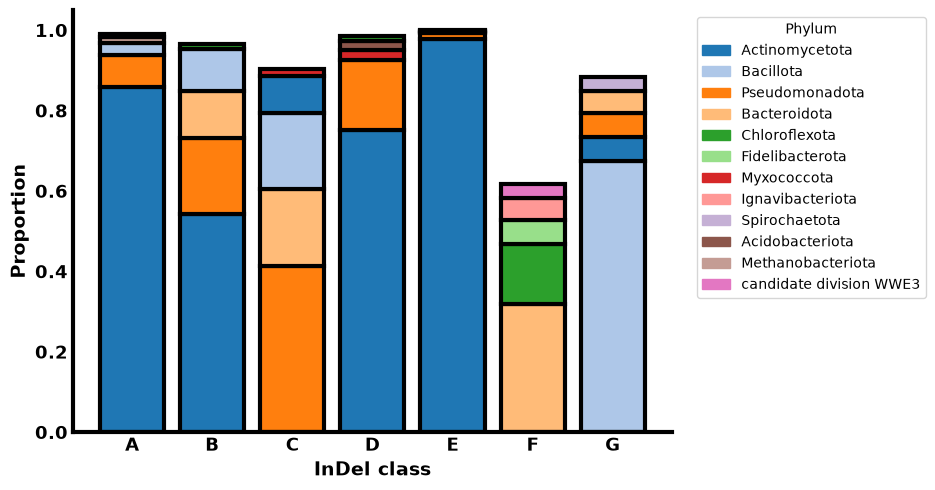

In [88]:
# ==== Supplementary Figure 9 — top-5 phyla per InDel class (styled; run SETUP first) ====
import matplotlib.pyplot as plt
FIG_DIR = "../results/figures"; os.makedirs(FIG_DIR, exist_ok=True)
TOP_N = 5
DROP_UNASSIGNED_PHYLUM = True                                          # <- True: proportions among proteins with a known phylum

sf9_tab = (ic_tab_phylum.drop(index="Unassigned", errors="ignore")     # <-
           if DROP_UNASSIGNED_PHYLUM else ic_tab_phylum)
prop = sf9_tab / sf9_tab.sum()                                         # <-
top  = {c: prop[c].nlargest(TOP_N) for c in IC_CLASSES}
top  = {c: s[s > 0] for c, s in top.items()}                         # drop zero-count "top-5" entries

# fixed colours so each phylum keeps the colour used in the original Supplementary Figure 9
PHYLUM_COLOURS = {
    "Actinomycetota": "#1f77b4", "Bacillota": "#aec7e8", "Pseudomonadota": "#ff7f0e",
    "Bacteroidota": "#ffbb78", "Chloroflexota": "#2ca02c", "Fidelibacterota": "#98df8a",
    "Myxococcota": "#d62728", "Ignavibacteriota": "#ff9896", "Candidatus Roizmaniibacteriota": "#9467bd",
    "Spirochaetota": "#c5b0d5", "Acidobacteriota": "#8c564b", "Methanobacteriota": "#c49c94",
    "Abditibacteriota": "#e377c2", "Unassigned": "#d9d9d9",
}
plotted = {p for s in top.values() for p in s.index}
spare = iter([c for c in plt.get_cmap("tab20").colors[12:]] + list(plt.get_cmap("Set3").colors))
colours = {p: PHYLUM_COLOURS.get(p) or next(spare) for p in sorted(plotted)}   # new phyla get unused colours
legend_order = ([p for p in PHYLUM_COLOURS if p in plotted and p != "Unassigned"]
                + sorted(plotted - set(PHYLUM_COLOURS))
                + (["Unassigned"] if "Unassigned" in plotted else []))

plt.rcParams.update({"font.family": "sans-serif", "font.weight": "bold",
                     "axes.labelweight": "bold", "axes.linewidth": 3})
fig, ax = plt.subplots(figsize=(9.5, 5))
for x, c in enumerate(IC_CLASSES):
    bottom = 0.0
    for p, v in top[c].sort_values(ascending=False).items():         # largest segment at the bottom
        ax.bar(x, v, bottom=bottom, width=0.8, color=colours[p], edgecolor="black", linewidth=3)
        bottom += v

ax.set_xticks(range(len(IC_CLASSES))); ax.set_xticklabels(IC_CLASSES)
ax.set_xlabel("InDel class", fontsize=14); ax.set_ylabel("Proportion", fontsize=14)
ax.tick_params(axis="both", labelsize=13, width=0, length=0)
ax.set_ylim(0, 1.05)
for s in ("top", "right"): ax.spines[s].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=colours[p]) for p in legend_order]
leg = ax.legend(handles, legend_order, title="Phylum", bbox_to_anchor=(1.03, 1), loc="upper left",
                frameon=True, fontsize=10, title_fontsize=10)
for t in leg.get_texts(): t.set_fontweight("normal")
leg.get_title().set_fontweight("normal")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/SuppFig9_phylum_by_indel_class.pdf")
plt.savefig(f"{FIG_DIR}/SuppFig9_phylum_by_indel_class.png", dpi=600)
plt.show()
plt.rcParams.update(plt.rcParamsDefault)                             # don't leak the style into later figures

# source data: plotted proportions (top-5 per class) + the full counts they come from
(pd.DataFrame({c: top[c] for c in IC_CLASSES}).reindex(legend_order).fillna(0).T
   .rename_axis("InDel_class").to_csv(f"{IC_SRC_DIR}/SuppFig9_plotted_proportions.csv", encoding="utf-8-sig"))
sf9_tab.to_csv(f"{IC_SRC_DIR}/SuppFig9_counts_phylum_x_class.csv", encoding="utf-8-sig")   # <-

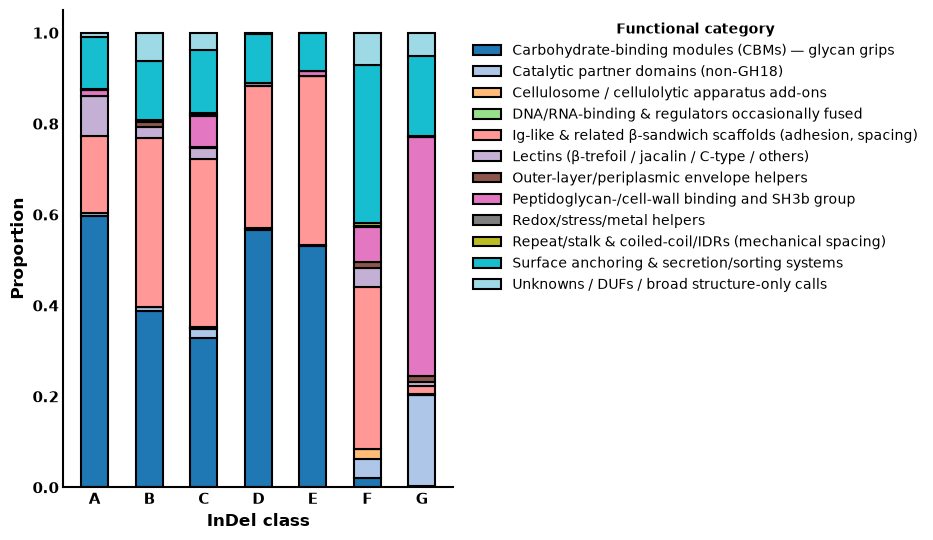

In [89]:
# ==== Supplementary Figure 10 — auxiliary-domain category composition per InDel class (styled) ====
import matplotlib.pyplot as plt
FIG_DIR = "../results/figures"; os.makedirs(FIG_DIR, exist_ok=True)

cprop = (ic_tab_category / ic_tab_category.sum())
order = sorted(cprop.index)                                           # alphabetical, as in the original
colours = dict(zip(order, plt.get_cmap("tab20")(np.linspace(0, 1, len(order)))))   # = pandas colormap="tab20"

plt.rcParams.update({"font.family": "sans-serif"})
fig, ax = plt.subplots(figsize=(9.5, 5.5))
bottom = np.zeros(len(IC_CLASSES))
for k in order:                                                       # first category at the bottom
    ax.bar(IC_CLASSES, cprop.loc[k], bottom=bottom, width=0.5, color=colours[k],
           edgecolor="black", linewidth=1.5, label=k)
    bottom += cprop.loc[k].values

ax.set_xlabel("InDel class", fontsize=12, fontweight="bold")
ax.set_ylabel("Proportion", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="both", labelsize=11, length=0)
for lab in ax.get_xticklabels() + ax.get_yticklabels(): lab.set_fontweight("bold")
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_linewidth(1.5); ax.spines[s].set_color("black")
leg = ax.legend(title="Functional category", bbox_to_anchor=(1.02, 1), loc="upper left",
                frameon=False, fontsize=10, title_fontsize=10)
leg.get_title().set_fontweight("bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/SuppFig10_category_by_indel_class.pdf")
plt.savefig(f"{FIG_DIR}/SuppFig10_category_by_indel_class.png", dpi=600)
plt.show()

cprop.loc[order].T.rename_axis("InDel_class").to_csv(f"{IC_SRC_DIR}/SuppFig10_plotted_proportions.csv", encoding="utf-8-sig")
ic_tab_category.to_csv(f"{IC_SRC_DIR}/SuppFig10_counts_category_x_class.csv", encoding="utf-8-sig")

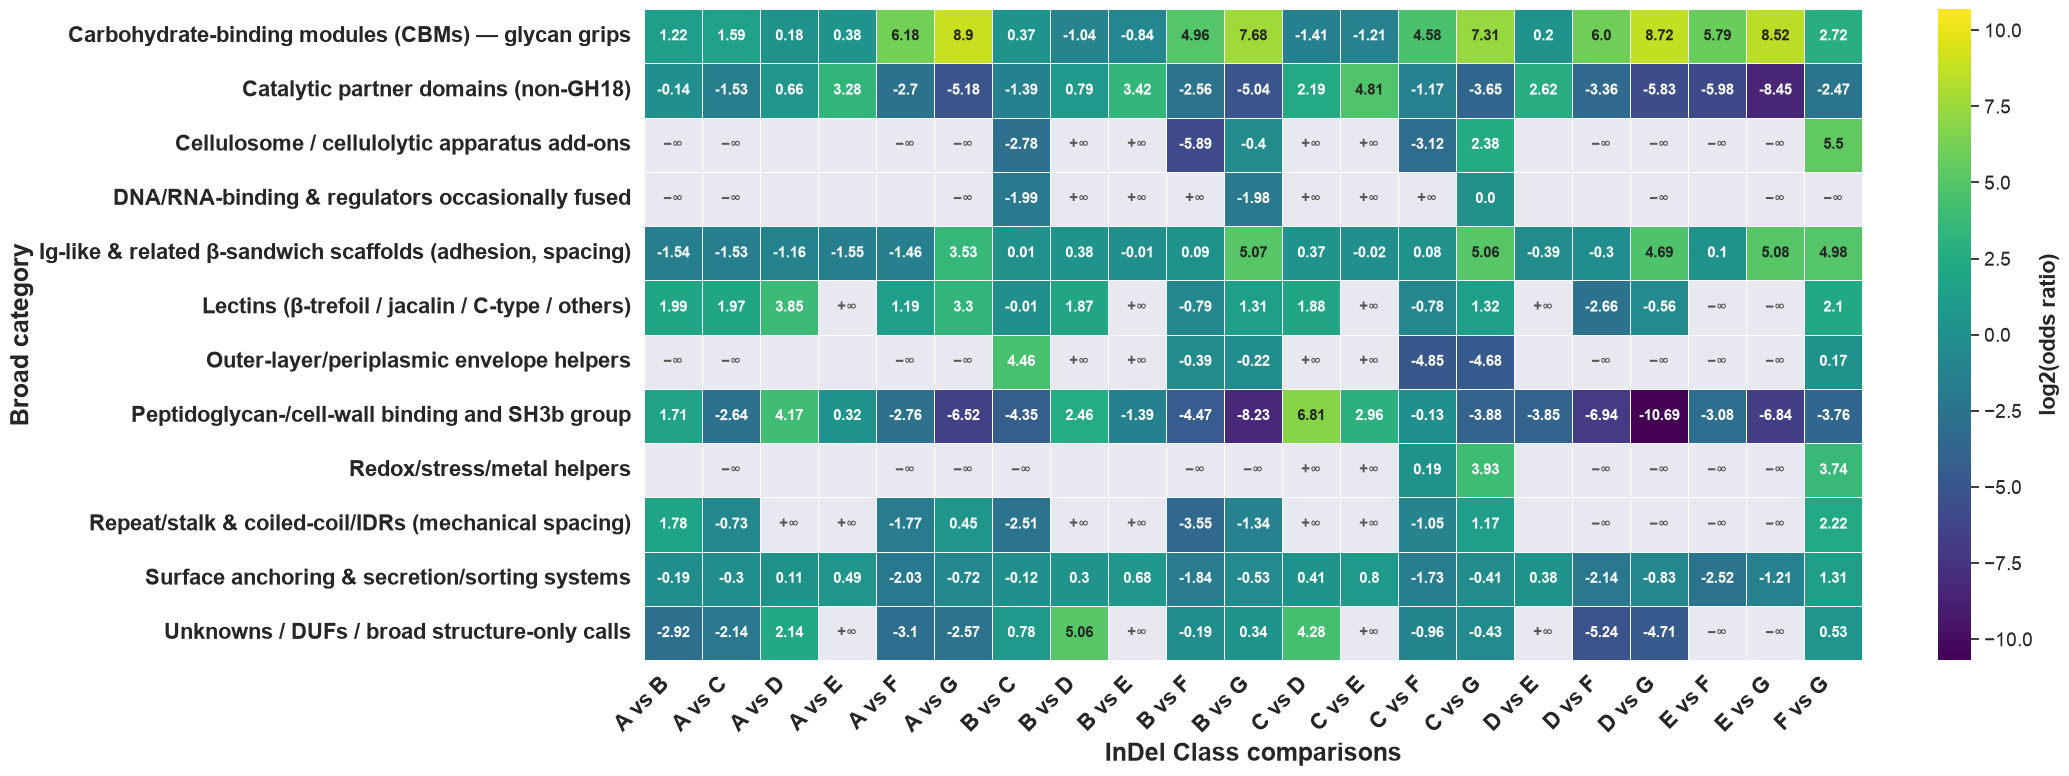

89 of 252 cells undefined: 70 shown as ±∞, 19 blank


In [103]:
# ==== Supplementary Figure 11 — pairwise log2(OR) heatmap: categories x InDel class pairs (styled) ====
import itertools
import seaborn as sns
CORRECTION = None     # None: OR undefined (grey) when any 2x2 cell is 0; 0.5: Haldane correction, no blanks
MARK_FDR   = None     # e.g. 0.05 to append "*" to annotations with BH-adjusted Fisher P < 0.05; None = original look

rows = []
N = ic_tab_category.sum()
for c1, c2 in itertools.combinations(IC_CLASSES, 2):
    for k in ic_tab_category.index:
        a, c = ic_tab_category.loc[k, c1], ic_tab_category.loc[k, c2]
        b, d = N[c1] - a, N[c2] - c
        if CORRECTION is None:
            l2 = np.log2((a * d) / (b * c)) if min(a, b, c, d) > 0 else np.nan
        else:
            l2 = np.log2(((a + CORRECTION) * (d + CORRECTION)) / ((b + CORRECTION) * (c + CORRECTION)))
        rows.append({"comparison": f"{c1} vs {c2}", "class_1": c1, "class_2": c2, "category": k,
                     "count_1": int(a), "total_1": int(N[c1]), "count_2": int(c), "total_2": int(N[c2]),
                     "log2_OR": l2, "p": fisher_exact([[a, b], [c, d]])[1]})
pw = pd.DataFrame(rows); pw["FDR"] = ic_bh(pw.p)

cats  = sorted(pw.category.unique())                                  # rows alphabetical, as in the originalmat = pw.pivot(index="category", columns="comparison", values="log2_OR").loc[cats, comps]
fdr = pw.pivot(index="category", columns="comparison", values="FDR").loc[cats, comps]
annot = mat.round(2).astype(object).where(mat.notna(), "")
if MARK_FDR:
    annot = annot.where(~((fdr < MARK_FDR) & mat.notna()), annot.astype(str) + "*")

# ±∞ where the category is absent from exactly one class of the pair (blank if absent from both)
a1 = pw.pivot(index="category", columns="comparison", values="count_1").loc[cats, comps]
a2 = pw.pivot(index="category", columns="comparison", values="count_2").loc[cats, comps]
inf_lab = (pd.DataFrame("", index=cats, columns=comps)
             .mask((a1 == 0) & (a2 > 0), "−∞").mask((a1 > 0) & (a2 == 0), "+∞"))

lim = np.nanmax(np.abs(mat.values))

sns.set(style="white", font_scale=1.2)
fig, ax = plt.subplots(figsize=(22, 8))
sns.heatmap(mat, cmap="viridis", vmin=-lim, vmax=lim, annot=annot, fmt="",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "log2(odds ratio)"},
            annot_kws={"size": 11, "weight": "bold"}, ax=ax)
ax.set_facecolor("#e8e8f0")                                           # undefined cells (as in original)
# seaborn never annotates NaN cells, so write the ±∞ labels onto the grey cells directly
for i, j in zip(*np.where(inf_lab.values != "")):
    ax.text(j + 0.5, i + 0.5, inf_lab.values[i, j], ha="center", va="center",
            fontsize=11, fontweight="bold", color="#555555")
ax.set_xlabel("InDel Class comparisons", fontsize=18, fontweight="bold")
ax.set_ylabel("Broad category", fontsize=18, fontweight="bold")
plt.xticks(fontsize=16, fontweight="bold", rotation=45, ha="right")
plt.yticks(fontsize=16, fontweight="bold", rotation=0)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14); cbar.set_label("log2(odds ratio)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/SuppFig11_pairwise_log2OR_heatmap.pdf")
plt.savefig(f"{FIG_DIR}/SuppFig11_pairwise_log2OR_heatmap.png", dpi=600)
plt.show()
sns.reset_orig()                                                      # don't leak seaborn style into later cells

pw.to_csv(f"{IC_SRC_DIR}/SuppFig11_pairwise_tests.csv", index=False, encoding="utf-8-sig")
print(f"{pw.log2_OR.isna().sum()} of {len(pw)} cells undefined: "
      f"{(inf_lab.values != '').sum()} shown as ±∞, {pw.log2_OR.isna().sum() - (inf_lab.values != '').sum()} blank")

source data files

In [91]:
# ==== Source Data — Supplementary Figures 9–11 (run SETUP and the three figure cells first) ====
# Unit = protein (UniProt Entry) per InDel class: a protein is counted once in each class its GH18 domains
# fall in, so Entry (not fastaID, which identifies a single GH18 domain) is the appropriate identifier.
SD = IC_SRC_DIR
CLASS2CID = {v: k for k, v in IC_CID2CLASS.items()}

# ---------- Supplementary Figure 9 ----------
sf9_raw = (ic_units[["Entry", "query_name", "phylum"]]
             .loc[lambda x: ~(DROP_UNASSIGNED_PHYLUM & (x.phylum == "Unassigned"))]
             .assign(InDel_class=lambda x: x.query_name.map(IC_CID2CLASS))
             .sort_values(["InDel_class", "Entry"]).reset_index(drop=True))
sf9_prop = (pd.crosstab(sf9_raw.phylum, sf9_raw.InDel_class).reindex(columns=IC_CLASSES, fill_value=0)
              .pipe(lambda t: t / t.sum()))                                   # all phyla, proportion of class
sf9_prop["plotted_in_top5_of"] = [",".join(c for c in IC_CLASSES if p in top[c].index) for p in sf9_prop.index]
sf9_raw.to_csv(f"{SD}/SuppFig9_raw_Entry_query_name_phylum.csv", index=False, encoding="utf-8-sig")
sf9_prop.rename_axis("phylum").to_csv(f"{SD}/SuppFig9_proportions.csv", encoding="utf-8-sig")

# ---------- Supplementary Figure 10 ----------
sf10_raw = (ic_ann.assign(query_name=lambda x: x.indel_class.map(CLASS2CID))
                  .rename(columns={"indel_class": "InDel_class"})
                  [["Entry", "query_name", "InDel_class", "broad_category"]]
                  .sort_values(["InDel_class", "Entry"]).reset_index(drop=True))
sf10_prop = (pd.crosstab(sf10_raw.broad_category, sf10_raw.InDel_class)
               .reindex(columns=IC_CLASSES, fill_value=0).pipe(lambda t: t / t.sum()))
sf10_raw.to_csv(f"{SD}/SuppFig10_raw_Entry_query_name_broad_category.csv", index=False, encoding="utf-8-sig")
sf10_prop.rename_axis("broad_category").to_csv(f"{SD}/SuppFig10_proportions.csv", encoding="utf-8-sig")

# ---------- Supplementary Figure 11 ----------
sf11 = pw.copy()
b1, b2 = sf11.total_1 - sf11.count_1, sf11.total_2 - sf11.count_2
num, den = sf11.count_1 * b2, b1 * sf11.count_2
sf11["odds_ratio"] = np.where(den > 0, num / den.replace(0, np.nan), np.where(num > 0, np.inf, np.nan))
sf11["odds_ratio_status"] = np.select([(num == 0) & (den == 0), den == 0, num == 0],
                                      ["undefined", "infinite", "zero"], "finite")
sf11["plotted_log2_OR"] = sf11.log2_OR                                        # NaN = blank cell in the figure
sf11 = sf11.rename(columns={"class_1": "InDel_class_1", "class_2": "InDel_class_2",
                            "count_1": "category_count_1", "total_1": "all_annotations_1",
                            "count_2": "category_count_2", "total_2": "all_annotations_2",
                            "p": "fisher_p", "FDR": "fisher_p_BH"})
sf11 = sf11[["comparison", "InDel_class_1", "InDel_class_2", "category",
             "category_count_1", "all_annotations_1", "category_count_2", "all_annotations_2",
             "odds_ratio", "odds_ratio_status", "plotted_log2_OR", "fisher_p", "fisher_p_BH"]]
sf11.to_csv(f"{SD}/SuppFig11_pairwise_odds_ratios.csv", index=False, encoding="utf-8-sig")

# ---------- round-trip checks: every plotted value is recomputable from the raw files ----------
r9 = pd.read_csv(f"{SD}/SuppFig9_raw_Entry_query_name_phylum.csv", encoding="utf-8-sig")
t9 = pd.crosstab(r9.phylum, r9.query_name.map(IC_CID2CLASS)).reindex(columns=IC_CLASSES, fill_value=0)
assert np.allclose((t9 / t9.sum()).loc[sf9_prop.index, IC_CLASSES], sf9_prop[IC_CLASSES])
assert all(np.isclose(sf9_prop.loc[p, c], v) for c in IC_CLASSES for p, v in top[c].items())   # = plotted bars
r10 = pd.read_csv(f"{SD}/SuppFig10_raw_Entry_query_name_broad_category.csv", encoding="utf-8-sig")
t10 = pd.crosstab(r10.broad_category, r10.query_name.map(IC_CID2CLASS)).reindex(columns=IC_CLASSES, fill_value=0)
assert np.allclose((t10 / t10.sum()).loc[sf10_prop.index], sf10_prop)
assert np.allclose(sf10_prop.loc[cprop.index], cprop)                                           # = plotted bars
chk = t10.sum()
assert (sf11.all_annotations_1 == sf11.InDel_class_1.map(chk)).all()
assert np.allclose(sf11.set_index(["category", "comparison"]).plotted_log2_OR.unstack().loc[mat.index, mat.columns],
                   mat, equal_nan=True)                                                          # = plotted heatmap

print(f"SF9 : {len(sf9_raw):,} protein–class rows | proportions for {len(sf9_prop)} phyla")
print(f"SF10: {len(sf10_raw):,} auxiliary {IC_AUX_COUNT}s | proportions for {len(sf10_prop)} categories")
print(f"SF11: {len(sf11)} comparisons x categories | status: {sf11.odds_ratio_status.value_counts().to_dict()}")

SF9 : 38,311 protein–class rows | proportions for 120 phyla
SF10: 52,968 auxiliary annotations | proportions for 12 categories
SF11: 252 comparisons x categories | status: {'finite': 163, 'zero': 40, 'infinite': 30, 'undefined': 19}


Supp Tables

In [109]:
# ==== Supplementary Tables 22–24 — helpers (run SETUP first) ====
IC_FDR_MAX, IC_N_SHOW = 0.05, 5      # rows shown in Tables 23–24; all tests go to Source Data

def ic_enrichment(tab):
    """Each class vs all other classes combined; +0.5 continuity correction for log2 OR; two-sided Fisher; BH over all tests."""
    N, tot = tab.sum(), tab.values.sum(); rows = []
    for c in tab.columns:
        for k in tab.index:
            a = int(tab.loc[k, c]); b = int(N[c]) - a; cc = int(tab.loc[k].sum()) - a; d = int(tot - N[c]) - cc
            rows.append({"InDel_class": c, "level": k, "count": a, "class_total": int(N[c]),
                         "pct_of_class": 100 * a / N[c],
                         "log2_OR": np.log2(((a + .5) * (d + .5)) / ((b + .5) * (cc + .5))),
                         "p": fisher_exact([[a, b], [cc, d]])[1]})
    r = pd.DataFrame(rows); r["FDR"] = ic_bh(r.p)
    r["direction"] = np.where(r.log2_OR > 0, "enriched", "depleted")
    return r

def ic_select(r):
    sig = r[r.FDR < IC_FDR_MAX]
    return pd.concat([pd.concat([g[g.direction == "enriched"].nlargest(IC_N_SHOW, "log2_OR"),
                                 g[g.direction == "depleted"].nsmallest(IC_N_SHOW, "log2_OR")])
                      for _, g in sig.groupby("InDel_class")]).reset_index(drop=True)

def ic_format(r, level_name, with_p=True):
    out = pd.DataFrame({"InDel Class": r.InDel_class, level_name: r.level, "Direction": r.direction,
                        "Count (% of class)": [f"{n} ({p:.2g}%)" for n, p in zip(r["count"], r.pct_of_class)],
                        "Log2(odds ratio)": r.log2_OR.round(2)})
    if with_p: out["p-value"] = r.p.map(lambda v: f"{v:.2g}")
    out["FDR (p-value)"] = r.FDR.map(lambda v: f"{v:.2g}")
    return out

# write a final table to CSV (opens in Excel) and TSV (pastes into Word), and show it untruncated
TABLE_DIR = "../results/tables"; os.makedirs(TABLE_DIR, exist_ok=True)
COPY_TO_CLIPBOARD = False     # True: also copy the table to the clipboard, ready to paste

def save_table(df, name):
    df.to_csv(f"{TABLE_DIR}/{name}.csv", index=False, encoding="utf-8-sig")
    df.to_csv(f"{TABLE_DIR}/{name}.tsv", index=False, sep="\t", encoding="utf-8")
    if COPY_TO_CLIPBOARD:
        df.to_clipboard(index=False)
    print(f"{name}: {len(df)} rows -> {TABLE_DIR}/{name}.csv / .tsv")
    with pd.option_context("display.max_rows", None, "display.max_columns", None,
                           "display.width", None, "display.max_colwidth", None):
        display(df)

In [110]:
# ==== Supplementary Table 22 — five most common phyla per InDel class (proteins with an assigned phylum) ====
_ph = ic_tab_phylum.drop(index="Unassigned", errors="ignore")
st22 = pd.DataFrame([{"InDel Class": c, "Phylum": k, "count": int(v),
                      "Proportion of InDel Class (%)": round(100 * v / _ph[c].sum(), 2)}
                     for c in IC_CLASSES
                     for k, v in _ph[c][_ph[c] > 0].nlargest(5).items()])
save_table(st22, "Supplementary_Table_22")
st22

Supplementary_Table_22: 35 rows -> ../results/tables/Supplementary_Table_22.csv / .tsv


,InDel Class,Phylum,count,Proportion of InDel Class (%)
0,A,Actinomycetota,2880,85.77
1,A,Pseudomonadota,270,8.04
2,A,Bacillota,98,2.92
3,A,Methanobacteriota,52,1.55
4,A,Chloroflexota,26,0.77
5,B,Actinomycetota,4117,54.23
6,B,Pseudomonadota,1442,18.99
7,B,Bacteroidota,877,11.55
8,B,Bacillota,799,10.52
9,B,Chloroflexota,90,1.19


,InDel Class,Phylum,count,Proportion of InDel Class (%)
0,A,Actinomycetota,2880,85.77
1,A,Pseudomonadota,270,8.04
2,A,Bacillota,98,2.92
3,A,Methanobacteriota,52,1.55
4,A,Chloroflexota,26,0.77
5,B,Actinomycetota,4117,54.23
6,B,Pseudomonadota,1442,18.99
7,B,Bacteroidota,877,11.55
8,B,Bacillota,799,10.52
9,B,Chloroflexota,90,1.19


In [111]:
# ==== Supplementary Table 23 — phylum enrichment/depletion per InDel class ("Unassigned" not tested) ====
st23_all = ic_enrichment(ic_tab_phylum.drop(index="Unassigned", errors="ignore"))
st23 = ic_format(ic_select(st23_all), "Phylum")
save_table(st23, "Supplementary_Table_23")
st23

Supplementary_Table_23: 61 rows -> ../results/tables/Supplementary_Table_23.csv / .tsv


,InDel Class,Phylum,Direction,Count (% of class),Log2(odds ratio),p-value,FDR (p-value)
0,A,Actinomycetota,enriched,2880 (86%),3.92,0,0
1,A,Methanobacteriota,enriched,52 (1.5%),1.68,5.9e-11,7.4e-10
2,A,Bacteroidota,depleted,0 (0%),-9.70,3.4e-162,1.6e-160
3,A,Spirochaetota,depleted,0 (0%),-6.37,2.1e-17,3.3e-16
4,A,Verrucomicrobiota,depleted,0 (0%),-5.50,7.6e-10,8.6e-09
5,A,Ignavibacteriota,depleted,0 (0%),-4.75,5.9e-06,4.5e-05
6,A,Myxococcota,depleted,1 (0.03%),-4.72,3.7e-15,5.6e-14
7,B,Chlamydiota,enriched,15 (0.2%),2.02,0.00021,0.0013
8,B,Actinomycetota,enriched,4117 (54%),1.59,0,0
9,B,Mycoplasmatota,enriched,34 (0.45%),0.97,0.0021,0.011


,InDel Class,Phylum,Direction,Count (% of class),Log2(odds ratio),p-value,FDR (p-value)
0,A,Actinomycetota,enriched,2880 (86%),3.92,0,0
1,A,Methanobacteriota,enriched,52 (1.5%),1.68,5.9e-11,7.4e-10
2,A,Bacteroidota,depleted,0 (0%),-9.70,3.4e-162,1.6e-160
3,A,Spirochaetota,depleted,0 (0%),-6.37,2.1e-17,3.3e-16
4,A,Verrucomicrobiota,depleted,0 (0%),-5.50,7.6e-10,8.6e-09
...,...,...,...,...,...,...,...
56,G,Candidatus Collieribacteriota,depleted,0 (0%),-4.61,5.8e-05,0.00039
57,G,Chlamydiota,depleted,0 (0%),-4.61,5.8e-05,0.00039
58,G,Fibrobacterota,depleted,1 (0.0092%),-3.89,2.8e-07,2.5e-06
59,G,Caldifarciminota,depleted,0 (0%),-3.80,0.0054,0.026


In [112]:
# ==== Supplementary Table 24 — auxiliary-domain category enrichment/depletion per InDel class ====
st24_all = ic_enrichment(ic_tab_category)
st24 = ic_format(ic_select(st24_all), "Broad category", with_p=False)
save_table(st24, "Supplementary_Table_24")
st24

Supplementary_Table_24: 56 rows -> ../results/tables/Supplementary_Table_24.csv / .tsv


,InDel Class,Broad category,Direction,Count (% of class),Log2(odds ratio),FDR (p-value)
0,A,Lectins (β-trefoil / jacalin / C-type / others),enriched,454 (8.9%),2.41,1.3e-137
1,A,Carbohydrate-binding modules (CBMs) — glycan grips,enriched,3037 (60%),1.98,0
2,A,Outer-layer/periplasmic envelope helpers,depleted,0 (0%),-6.07,5.3e-14
3,A,Peptidoglycan-/cell-wall binding and SH3b group,depleted,61 (1.2%),-4.10,1.4e-298
4,A,Cellulosome / cellulolytic apparatus add-ons,depleted,0 (0%),-3.87,0.0023
5,A,Catalytic partner domains (non-GH18),depleted,35 (0.69%),-3.31,1.8e-93
6,A,DNA/RNA-binding & regulators occasionally fused,depleted,0 (0%),-3.24,0.025
7,B,Outer-layer/periplasmic envelope helpers,enriched,125 (1.1%),1.25,1.4e-12
8,B,"Ig-like & related β-sandwich scaffolds (adhesion, spacing)",enriched,4330 (37%),1.01,1e-203
9,B,Unknowns / DUFs / broad structure-only calls,enriched,734 (6.3%),0.94,2.5e-40


,InDel Class,Broad category,Direction,Count (% of class),Log2(odds ratio),FDR (p-value)
0,A,Lectins (β-trefoil / jacalin / C-type / others),enriched,454 (8.9%),2.41,1.3e-137
1,A,Carbohydrate-binding modules (CBMs) — glycan g...,enriched,3037 (60%),1.98,0
2,A,Outer-layer/periplasmic envelope helpers,depleted,0 (0%),-6.07,5.3e-14
3,A,Peptidoglycan-/cell-wall binding and SH3b group,depleted,61 (1.2%),-4.10,1.4e-298
4,A,Cellulosome / cellulolytic apparatus add-ons,depleted,0 (0%),-3.87,0.0023
5,A,Catalytic partner domains (non-GH18),depleted,35 (0.69%),-3.31,1.8e-93
6,A,DNA/RNA-binding & regulators occasionally fused,depleted,0 (0%),-3.24,0.025
7,B,Outer-layer/periplasmic envelope helpers,enriched,125 (1.1%),1.25,1.4e-12
8,B,Ig-like & related β-sandwich scaffolds (adhesi...,enriched,4330 (37%),1.01,1e-203
9,B,Unknowns / DUFs / broad structure-only calls,enriched,734 (6.3%),0.94,2.5e-40


In [107]:
# ==== Source Data for Supplementary Tables 22–24 ====
ic_units[["Entry", "fastaID", "query_name", "indel_class", "phylum"]].to_csv(
    f"{IC_SRC_DIR}/STable22_23_per_sequence.csv", index=False, encoding="utf-8-sig")
st23_all.to_csv(f"{IC_SRC_DIR}/STable23_all_tests.csv", index=False, encoding="utf-8-sig")
ic_ann.to_csv(f"{IC_SRC_DIR}/STable24_per_annotation.csv", index=False, encoding="utf-8-sig")
st24_all.to_csv(f"{IC_SRC_DIR}/STable24_all_tests.csv", index=False, encoding="utf-8-sig")

# round trip: tables must be recomputable from the per-unit files
_chk = pd.read_csv(f"{IC_SRC_DIR}/STable22_23_per_sequence.csv", encoding="utf-8-sig")
assert pd.crosstab(_chk.phylum, _chk.indel_class).reindex(columns=IC_CLASSES, fill_value=0).equals(ic_tab_phylum)
_chk = pd.read_csv(f"{IC_SRC_DIR}/STable24_per_annotation.csv", encoding="utf-8-sig")
assert pd.crosstab(_chk.broad_category, _chk.indel_class).reindex(columns=IC_CLASSES, fill_value=0).equals(ic_tab_category)
print("Source Data for Supplementary Tables 22–24 written to", IC_SRC_DIR)

Source Data for Supplementary Tables 22–24 written to ../results/source_data
